In [1]:
# Cell 1: Setup
import re
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")
search_tool = TavilySearchResults(max_results=2)
import operator
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langgraph.types import Send

c:\Users\shiva\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\shiva\AppData\Local\Temp\ipykernel_17132\1751451531.py:10: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=2)


In [2]:
# Cell 2: State
class State(TypedDict):
    messages: list
    results: Annotated[list, operator.add]  # merges parallel outputs instead of overwriting

In [3]:
# Cell 3: Workers
def add_agent(state: State) -> State:
    text = state["messages"][-1]
    nums = re.findall(r"\d+\.?\d*", text)
    result = f"add_agent: {float(nums[0]) + float(nums[1])}"
    return {"results": [result]}

def multiply_agent(state: State) -> State:
    text = state["messages"][-1]
    nums = re.findall(r"\d+\.?\d*", text)
    result = f"multiply_agent: {float(nums[0]) * float(nums[1])}"
    return {"results": [result]}

def web_search_agent(state: State) -> State:
    query = state["messages"][-1]
    search_results = search_tool.invoke(query)
    content = search_results[0]["content"] if search_results else "No results found."
    result = f"web_search_agent: {content[:200]}"
    return {"results": [result]}

In [4]:
# Cell 4: Aggregator node
def aggregator(state: State) -> State:
    summary = "\n".join(f"- {r}" for r in state["results"])
    final = f"Aggregated results:\n{summary}"
    return {"results": [final]}

In [5]:
# Cell 5: Fan-out function — dispatches all 3 workers simultaneously
def fan_out(state: State):
    return [
        Send("add_agent", state),
        Send("multiply_agent", state),
        Send("web_search_agent", state),
    ]

In [6]:
# Cell 6: Graph
builder = StateGraph(State)
builder.add_node("add_agent", add_agent)
builder.add_node("multiply_agent", multiply_agent)
builder.add_node("web_search_agent", web_search_agent)
builder.add_node("aggregator", aggregator)

builder.add_conditional_edges("__start__", fan_out, ["add_agent", "multiply_agent", "web_search_agent"])
builder.add_edge("add_agent", "aggregator")
builder.add_edge("multiply_agent", "aggregator")
builder.add_edge("web_search_agent", "aggregator")
builder.add_edge("aggregator", END)

app = builder.compile()

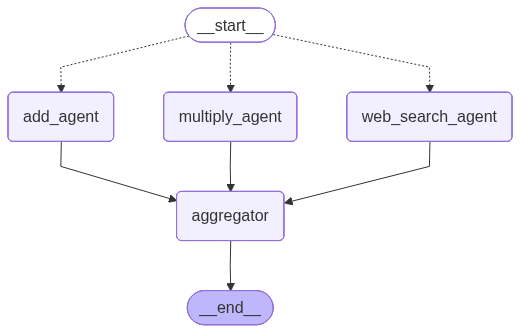

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
# Cell 7: Run
result = app.invoke({"messages": ["What is 8 multiplied by 3? and What is the purpose of MCP. Invoke only the necessary agents"], "results": []})
print("All results:")
for r in result["results"]:
    print(r)

All results:
add_agent: 11.0
multiply_agent: 24.0
web_search_agent: ð What is MCP (Model Context Protocol)? MCP is like a universal connector that allows AI models (like GPT, Claude, DeepSeek, etc.) to talk to tools, data, APIs, and even other models in a standard 
Aggregated results:
- add_agent: 11.0
- multiply_agent: 24.0
- web_search_agent: ð What is MCP (Model Context Protocol)? MCP is like a universal connector that allows AI models (like GPT, Claude, DeepSeek, etc.) to talk to tools, data, APIs, and even other models in a standard 
